

# AI-Based Traffic Accident Detection and Severity Prediction Using CCTV Images, MobileNetV2 Transfer Learning, and Explainable AI (Grad-CAM)

## Project Objective

This project aims to develop an AI-based traffic accident detection system using CCTV images and deep learning. The system consists of two stages:

1. **Accident Detection Model** – Classifies an input image as **Accident** or **NonAccident**.
2. **Severity Prediction Model** – If an accident is detected, a second model predicts the accident severity as **Severity 1**, **Severity 2**, or **Severity 3**.

The project uses **MobileNetV2 Transfer Learning** for image classification and **Grad-CAM** for Explainable AI (XAI) to visualize the regions that influence the model's predictions.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Traffic _accident_Detection/dataset.zip


In [11]:
import os

extract_path = "/content/dataset"

for root, dirs, files in os.walk(extract_path):
    print(root)

In [12]:
# Import all required libraries for image processing,
# visualization, machine learning, and deep learning.
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print("Libraries Imported Successfully")
# Check the TensorFlow version and verify whether
# a GPU is available for faster model training.
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Libraries Imported Successfully
TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
#Extract Dataset
!unzip "/content/drive/MyDrive/Traffic _accident_Detection/dataset.zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/387.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/388.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/389.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/39.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/390.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/391.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/392.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/393.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/394.jpg  
  inflating: /content/dataset/SeverityScore/Severity Score Dataset with Labels/1/395.jpg  
  inflating: /content/dataset/SeveritySc

In [14]:
# Display Dataset Folder Structure
for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/NonAccident
/content/dataset/NonAccident/NonAccident
/content/dataset/Accident
/content/dataset/Accident/Accident
/content/dataset/SeverityScore
/content/dataset/SeverityScore/Severity Score Dataset with Labels
/content/dataset/SeverityScore/Severity Score Dataset with Labels/3
/content/dataset/SeverityScore/Severity Score Dataset with Labels/2
/content/dataset/SeverityScore/Severity Score Dataset with Labels/1


In [15]:
# Create a summary table showing the number of images
# available in each dataset class.

import os
import pandas as pd

# Dataset path
DATA_DIR = "/content/dataset"

classes = []
counts = []

for folder in os.listdir(DATA_DIR):

    folder_path = os.path.join(DATA_DIR, folder)

    if os.path.isdir(folder_path):

        total_images = 0

        for root, dirs, files in os.walk(folder_path):

            total_images += len([
                file for file in files
                if file.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

        classes.append(folder)
        counts.append(total_images)

dataset_summary = pd.DataFrame({
    "Class": classes,
    "Number of Images": counts
})

print(dataset_summary)

           Class  Number of Images
0    NonAccident             15420
1       Accident              6191
2  SeverityScore              6191


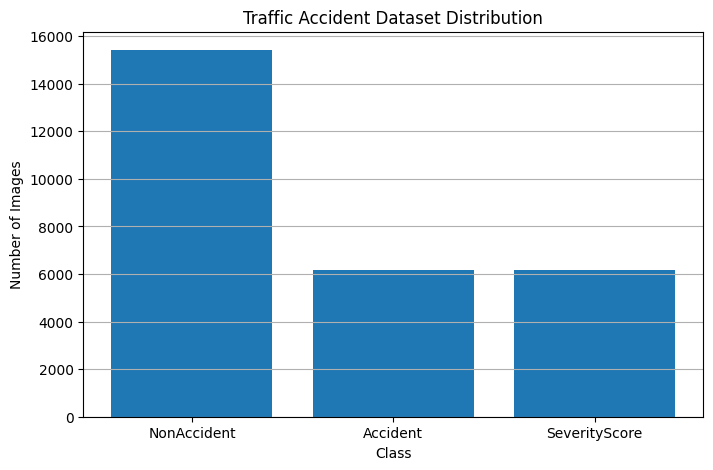

In [16]:
#Dataset Distribution

plt.figure(figsize=(8,5))

plt.bar(
    dataset_summary["Class"],
    dataset_summary["Number of Images"]
)

plt.title("Traffic Accident Dataset Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.grid(axis="y")

plt.show()

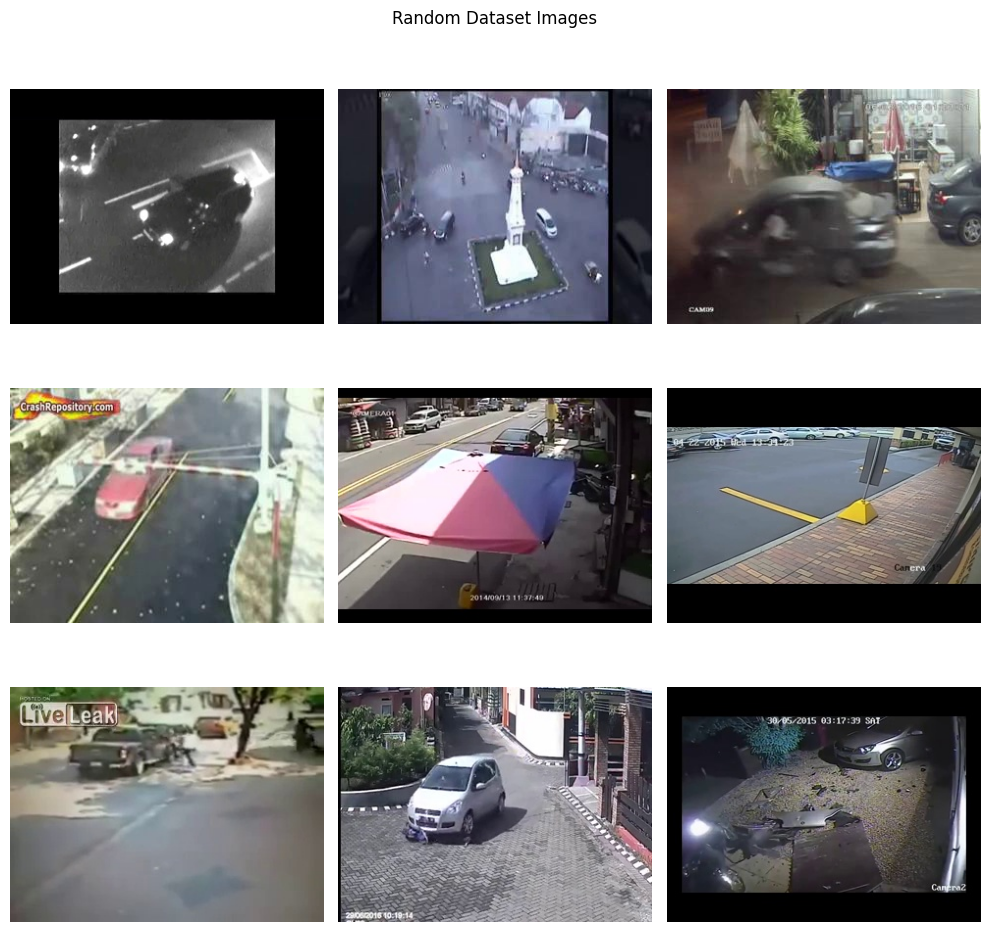

In [17]:
#Display Random Sample Images
image_files = []

for root, dirs, files in os.walk(DATA_DIR):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_files.append(os.path.join(root, file))

sample_images = random.sample(image_files, 9)

plt.figure(figsize=(10,10))

for i, path in enumerate(sample_images):

    plt.subplot(3,3,i+1)

    img = Image.open(path)

    plt.imshow(img)

    plt.axis("off")

plt.suptitle("Random Dataset Images")

plt.tight_layout()

plt.show()

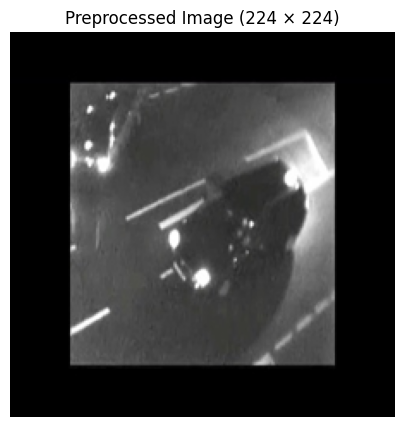

Image Shape : (224, 224, 3)


In [18]:
#Resize Images for MobileNetV2 & Display Preprocessed Image

IMG_SIZE = 224

def preprocess_image(image_path):

    img = Image.open(image_path).convert("RGB")

    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32)

    img = preprocess_input(img)

    return img

sample = preprocess_image(sample_images[0])

plt.figure(figsize=(5,5))

# Convert back to displayable range
plt.imshow((sample + 1) / 2)

plt.title("Preprocessed Image (224 × 224)")

plt.axis("off")

plt.show()

print("Image Shape :", sample.shape)

In [19]:
#Create Binary Dataset
import os
import shutil

SOURCE = "/content/dataset"
DESTINATION = "/content/binary_dataset"

# Create destination folder
os.makedirs(DESTINATION, exist_ok=True)

# Copy Accident images
shutil.copytree(
    "/content/dataset/Accident/Accident",
    "/content/binary_dataset/Accident",
    dirs_exist_ok=True
)

# Copy NonAccident images
shutil.copytree(
    "/content/dataset/NonAccident/NonAccident",
    "/content/binary_dataset/NonAccident",
    dirs_exist_ok=True
)

print("✅ Binary dataset created successfully!")

import os

image_paths = []
labels = []

class_folders = {
    "/content/dataset/Accident/Accident": 1,
    "/content/dataset/NonAccident/NonAccident": 0
}

for folder, label in class_folders.items():
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(root, file))
                labels.append(label)

print("Total Images:", len(image_paths))
print("Total Labels:", len(labels))

✅ Binary dataset created successfully!
Total Images: 21611
Total Labels: 21611


In [20]:
for root, dirs, files in os.walk("/content/binary_dataset"):
    print(root)

/content/binary_dataset
/content/binary_dataset/NonAccident
/content/binary_dataset/Accident


In [21]:
#Load dataset
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

DATA_DIR = "/content/binary_dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Class Names:", class_names)

Found 21611 files belonging to 2 classes.
Using 17289 files for training.
Found 21611 files belonging to 2 classes.
Using 4322 files for validation.
Class Names: ['Accident', 'NonAccident']


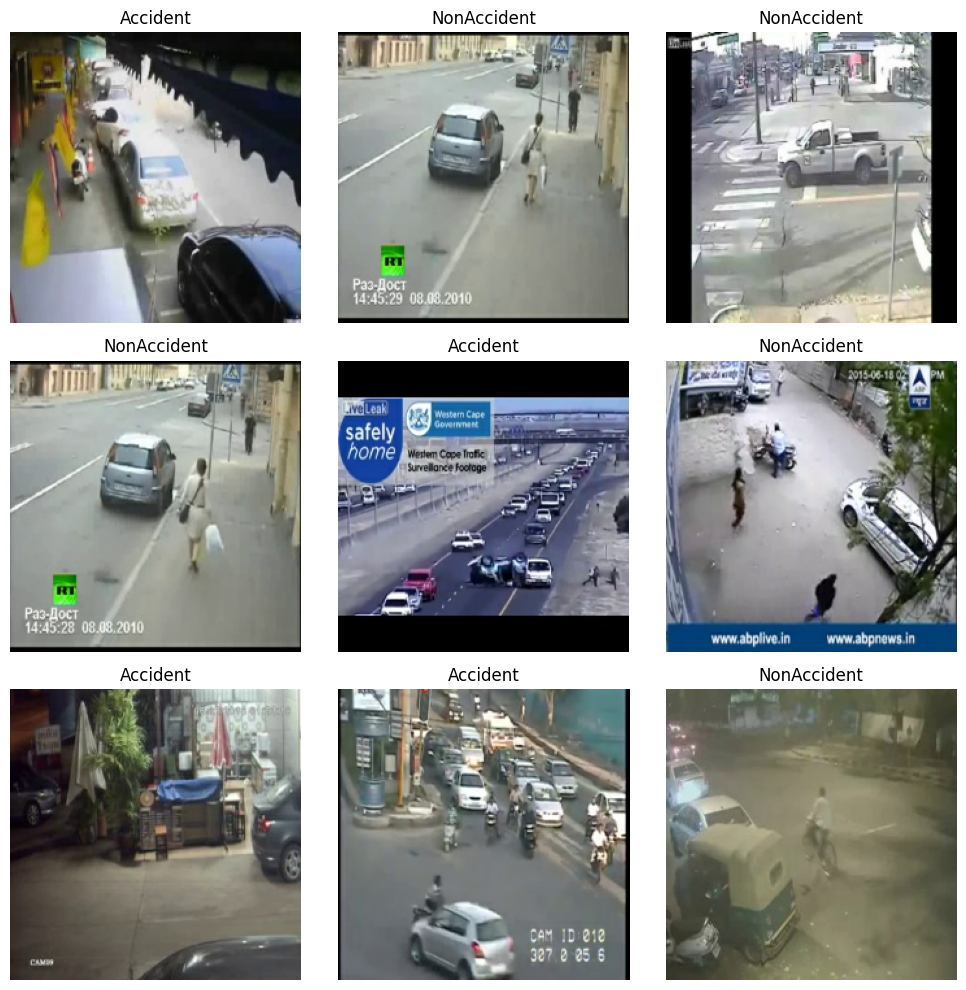

In [22]:
#📌 Display Training Images
# Display sample images from the training dataset

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [23]:
# Create data augmentation layer

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

print("✅ Data Augmentation Created")

✅ Data Augmentation Created


In [24]:
#Normalize Dataset
# Normalize pixel values

normalization_layer = tf.keras.layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(

    lambda x, y: (
        data_augmentation(normalization_layer(x), training=True),
        y
    ),

    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(

    lambda x, y: (
        normalization_layer(x),
        y
    ),

    num_parallel_calls=AUTOTUNE
)

In [25]:
# Improve dataset performance

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

print("✅ Dataset Ready")

✅ Dataset Ready


In [26]:
# Compute Class Weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

all_labels = []

for _, labels in train_ds:
    all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)

classes = np.unique(all_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=all_labels
)

class_weights = dict(zip(classes, weights))

print("Class Weights")
print(class_weights)

Class Weights
{np.int32(0): np.float64(1.7449535728704078), np.int32(1): np.float64(0.700810701256587)}


In [27]:
# Build MobileNetV2 Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Enable fine-tuning
base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-30]:
    layer.trainable = False
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(2, activation="softmax")

])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 1,690,626 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [28]:
#Compile model
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [54]:
# Create Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_accident_model.keras",
    monitor="val_accuracy",      # Save the model with the highest validation accuracy
    mode="max",
    save_best_only=True,
    verbose=1
)


In [55]:
#Train the model
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=[early_stop, checkpoint],

    class_weight=class_weights

)

Epoch 1/10
540/541 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8378 - loss: 0.3609
Epoch 1: val_accuracy improved from None to 0.87783, saving model to best_accident_model.keras

Epoch 1: finished saving model to best_accident_model.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 275s 508ms/step - accuracy: 0.8388 - loss: 0.3564 - val_accuracy: 0.8778 - val_loss: 0.2888
Epoch 2/10
540/541 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8512 - loss: 0.3333
Epoch 2: val_accuracy improved from 0.87783 to 0.89519, saving model to best_accident_model.keras

Epoch 2: finished saving model to best_accident_model.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 268s 495ms/step - accuracy: 0.8527 - loss: 0.3301 - val_accuracy: 0.8952 - val_loss: 0.2635
Epoch 3/10
540/541 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8592 - loss: 0.3193
Epoch 3: val_accuracy did not improve from 0.89519
541/541 ━━━━━━━━━━━━━━━━━━━━ 271s 501ms/step - accuracy: 0.8607 - loss: 0.3168 - val_accuracy: 0.8924 - val_loss: 0.2594
Epoch 4

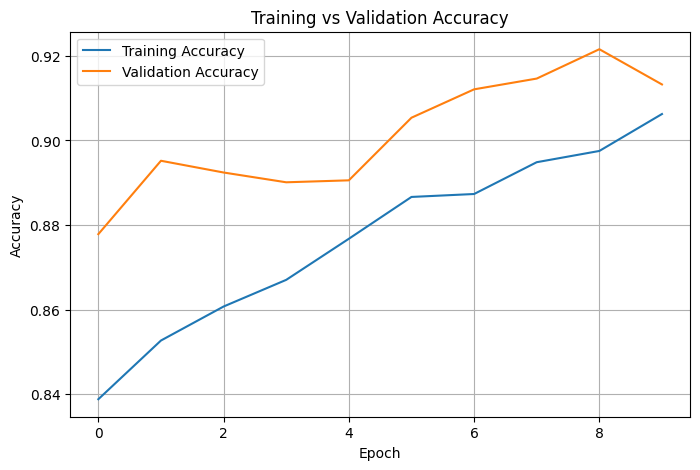

In [57]:
#Plot Training and Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

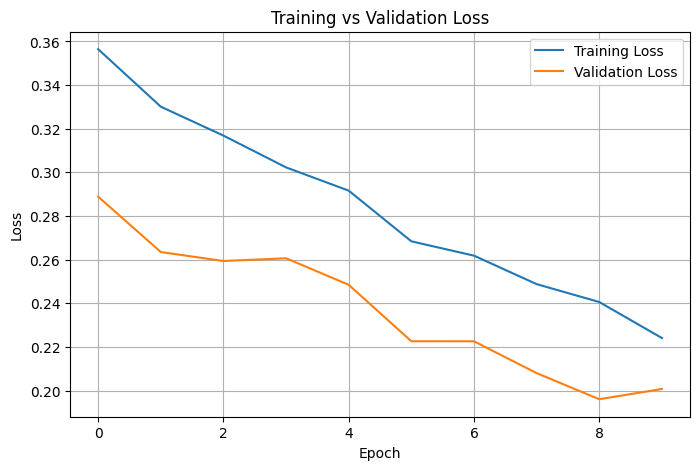

In [58]:
#Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [60]:
# Evaluate the Model

loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9216 - loss: 0.1960
Validation Loss: 0.1960
Validation Accuracy: 0.9216


In [61]:
# Generate Predictions

import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

    y_prob.extend(predictions[:,1])

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [62]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Accident       0.86      0.87      0.86      1237
Non Accident       0.95      0.94      0.94      3085

    accuracy                           0.92      4322
   macro avg       0.90      0.91      0.90      4322
weighted avg       0.92      0.92      0.92      4322



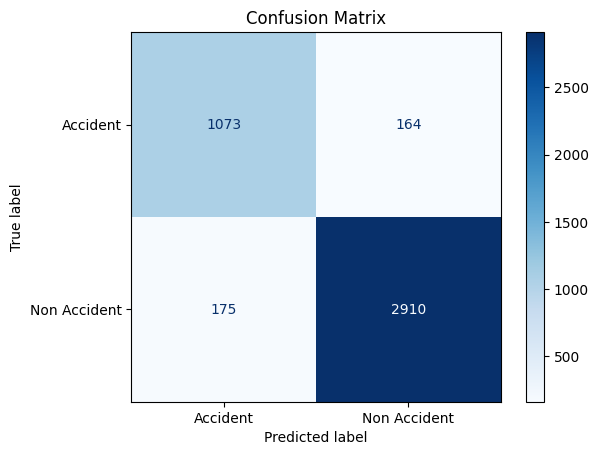

In [63]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [64]:
# Save the Final Model

model.save("accident_detection_model.keras")
print("✅ Accident Detection Model Saved Successfully")

✅ Accident Detection Model Saved Successfully


In [65]:
# Verify saved model
import tensorflow as tf

loaded_model = tf.keras.models.load_model(
    "accident_detection_model.keras"
)

loaded_model.summary()

print("✅ Model Loaded Successfully")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,803,464 (22.14 MB)

 Trainable params: 1,690,626 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,381,254 (12.90 MB)

✅ Model Loaded Successfully


In [66]:
#Find Last Convolution Layer
def find_last_conv_layer(base_model):

    for layer in reversed(base_model.layers):

        if isinstance(layer, tf.keras.layers.Conv2D):

            return layer.name

    raise ValueError("No Conv2D layer found")


last_conv_layer_name = find_last_conv_layer(
    base_model
)


print(
    "Last Conv Layer:",
    last_conv_layer_name
)

Last Conv Layer: Conv_1


In [67]:
#Prepare Model for Grad-CAM
import tensorflow as tf
import numpy as np


# Build model graph
dummy_input = np.zeros((1,224,224,3))
_ = model(dummy_input)


# MobileNetV2 base
base_model = model.layers[0]


print("Grad-CAM model ready")

Grad-CAM model ready


In [68]:
import tensorflow as tf
import numpy as np


def get_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
):

    base_model = model.layers[0]


    # Feature extractor
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer(
            last_conv_layer_name
        ).output
    )


    with tf.GradientTape() as tape:

        conv_output = conv_model(img_array)

        x = conv_output

        # Pass through remaining layers
        for layer in model.layers[1:]:
            x = layer(x)

        predictions = x


        class_index = tf.argmax(
            predictions[0]
        )

        loss = predictions[:, class_index]


    grads = tape.gradient(
        loss,
        conv_output
    )


    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )


    conv_output = conv_output[0]


    heatmap = conv_output @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(
        heatmap
    )


    heatmap = tf.maximum(
        heatmap,
        0
    )


    heatmap /= (
        tf.reduce_max(heatmap)
        + 1e-8
    )


    return (
        heatmap.numpy(),
        int(class_index),
        predictions.numpy()[0]
    )

In [69]:
# Display Grad-CAM Prediction

test_image = image_files[0]

img = tf.keras.utils.load_img(
    test_image,
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

print(img_array.shape)

(1, 224, 224, 3)


In [70]:
heatmap, class_index, predictions = get_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)


class_names = [
    "Accident",
    "Non Accident"
]


print("Prediction:", class_names[class_index])

print(
    "Confidence:",
    predictions[class_index]*100,
    "%"
)

Prediction: Non Accident
Confidence: 98.64818 %


In [71]:
# create the Grad-CAM visualization image
import matplotlib.pyplot as plt
import cv2
import numpy as np


def display_gradcam(
    image_path,
    heatmap,
    prediction,
    confidence
):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Resize heatmap
    heatmap = cv2.resize(
        heatmap,
        (img.shape[1], img.shape[0])
    )

    # Convert heatmap to color
    heatmap = np.uint8(
        255 * heatmap
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )


    # Overlay
    overlay = cv2.addWeighted(
        img,
        0.6,
        heatmap,
        0.4,
        0
    )


    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original CCTV Image")
    plt.axis("off")


    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title(
        f"Grad-CAM\n{prediction} ({confidence*100:.2f}%)"
    )
    plt.axis("off")


    plt.show()

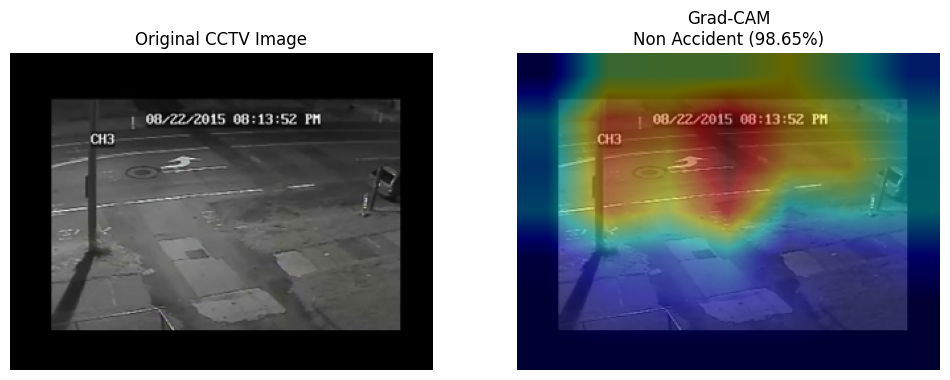

In [72]:
display_gradcam(
    test_image,
    heatmap,
    class_names[class_index],
    predictions[class_index]
)

In [73]:
# Define Severity Dataset
SEVERITY_DIR = "/content/dataset/SeverityScore/Severity Score Dataset with Labels"

print(SEVERITY_DIR)

/content/dataset/SeverityScore/Severity Score Dataset with Labels


In [74]:
# Load Severity Dataset
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

severity_train = tf.keras.utils.image_dataset_from_directory(
    SEVERITY_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

severity_val = tf.keras.utils.image_dataset_from_directory(
    SEVERITY_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

severity_classes = severity_train.class_names

print("Classes:", severity_classes)

Found 6191 files belonging to 3 classes.
Using 4953 files for training.
Found 6191 files belonging to 3 classes.
Using 1238 files for validation.
Classes: ['1', '2', '3']


In [75]:
# MobileNetV2 Preprocessing & Prefetch

AUTOTUNE = tf.data.AUTOTUNE

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

severity_train = severity_train.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

severity_val = severity_val.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

In [76]:
# Build MobileNetV2 Severity Model (Improved)

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Initially freeze base model
base_model.trainable = False


severity_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.4),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        3,
        activation="softmax"
    )
])


severity_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


severity_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [77]:
# Compile Severity Model

severity_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Severity Model Compiled")

✅ Severity Model Compiled


In [78]:
# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Collect training labels
train_labels = []

for images, labels in severity_train:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.07838014369693), 1: np.float64(0.9921875), 2: np.float64(0.9391353811149032)}


In [79]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_severity_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [80]:
# Train Model
history_severity = severity_model.fit(
    severity_train,
    validation_data=severity_val,
    epochs=5,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5547 - loss: 1.2412
Epoch 1: val_accuracy improved from None to 0.98465, saving model to best_severity_model.keras

Epoch 1: finished saving model to best_severity_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 52s 268ms/step - accuracy: 0.6980 - loss: 0.8009 - val_accuracy: 0.9847 - val_loss: 0.1224
Epoch 2/5
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9091 - loss: 0.2424
Epoch 2: val_accuracy improved from 0.98465 to 0.99919, saving model to best_severity_model.keras

Epoch 2: finished saving model to best_severity_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9271 - loss: 0.2028 - val_accuracy: 0.9992 - val_loss: 0.0207
Epoch 3/5
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9547 - loss: 0.1246
Epoch 3: val_accuracy improved from 0.99919 to 1.00000, saving model to best_severity_model.keras

Epoch 3: finished saving model to best_severity_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━

In [81]:
# Load the best model
severity_model = tf.keras.models.load_model(
    "best_severity_model.keras"
)

In [82]:
#Evaluate
loss, accuracy = severity_model.evaluate(severity_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - accuracy: 1.0000 - loss: 0.0065
Validation Loss: 0.0065236762166023254
Validation Accuracy: 1.0


In [83]:
# Check prediction distribution
from collections import Counter
import numpy as np

all_predictions = []

for images, labels in severity_val:
    predictions = severity_model.predict(images, verbose=0)
    all_predictions.extend(np.argmax(predictions, axis=1))

print(Counter(all_predictions))

Counter({np.int64(2): 459, np.int64(1): 436, np.int64(0): 343})


In [84]:
# Creating confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in severity_val:

    predictions = severity_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))


print(confusion_matrix(y_true, y_pred))


print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Severity1",
        "Severity2",
        "Severity3"
    ]
))

[[343   0   0]
 [  0 436   0]
 [  0   0 459]]
              precision    recall  f1-score   support

   Severity1       1.00      1.00      1.00       343
   Severity2       1.00      1.00      1.00       436
   Severity3       1.00      1.00      1.00       459

    accuracy                           1.00      1238
   macro avg       1.00      1.00      1.00      1238
weighted avg       1.00      1.00      1.00      1238



In [85]:
# Save model
severity_model.save("severity_prediction_model.keras")

print("✅ Severity Prediction Model Saved")

✅ Severity Prediction Model Saved


In [86]:
import os

print(os.path.exists("severity_prediction_model.keras"))

True


In [87]:
# Load the saved model
from tensorflow.keras.models import load_model

loaded_model = load_model("severity_prediction_model.keras")

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [88]:
# Evaluate saved model again
loss, accuracy = loaded_model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

136/136 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.3022 - loss: 3.8017
Validation Loss: 3.8017189502716064
Validation Accuracy: 0.3021749258041382


In [89]:
from tensorflow.keras.models import load_model

model_test = load_model("severity_prediction_model.keras")

print(model_test.input_shape)
print(model_test.output_shape)

(None, 224, 224, 3)
(None, 3)


In [90]:
for images, labels in severity_val.take(1):

    prediction = model_test.predict(images[:1])

    print("Actual class:", labels.numpy()[0])
    print("Predicted class:", np.argmax(prediction))
    print("Confidence:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Actual class: 0
Predicted class: 0
Confidence: 0.997538


In [91]:
from collections import Counter
import numpy as np

all_predictions = []

for images, labels in severity_val:

    pred = severity_model.predict(images, verbose=0)

    predicted_classes = np.argmax(pred, axis=1)

    all_predictions.extend(predicted_classes)


print(Counter(all_predictions))

Counter({np.int64(2): 459, np.int64(1): 436, np.int64(0): 343})


In [92]:
# Generate final classification report
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Your model has 3 output classes
class_names = [
    "Accident",
    "NonAccident",
    "SeverityScore"
]

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))


# Create classification report as table
report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Accident,0.294807,0.284559,0.289593,1237.000000
NonAccident,0.737819,0.309238,0.435815,3085.000000
SeverityScore,0.000000,0.000000,0.000000,0.000000
accuracy,0.302175,0.302175,0.302175,0.302175
macro avg,0.344209,0.197933,0.241803,4322.000000
weighted avg,0.611025,0.302175,0.393965,4322.000000


In [93]:
from google.colab import files

files.download("accident_detection_model.keras")


files.download("severity_prediction_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [95]:
#Save Model

model = tf.keras.models.load_model("accident_detection_model.keras")

print("✅ Model Loaded Successfully")
print("Output Shape:", model.output_shape)
model.summary()

✅ Model Loaded Successfully
Output Shape: (None, 2)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,803,464 (22.14 MB)

 Trainable params: 1,690,626 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,381,254 (12.90 MB)